In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_golden = pd.read_csv('California_Housing_TargetEncoded.csv', low_memory=False)

In [3]:
df_golden = pd.read_csv('California_Housing_TargetEncoded.csv', low_memory=False)
df_train = df_golden[df_golden['Set_Type'] == 'Train'].copy()
df_test = df_golden[df_golden['Set_Type'] == 'Test'].copy()

In [4]:
X_train = df_train.drop(columns=['ClosePrice', 'Set_Type'])
X_test = df_test.drop(columns=['ClosePrice', 'Set_Type'])
y_train = np.log1p(df_train['ClosePrice'])
y_test = np.log1p(df_test['ClosePrice'])

results_compare = []

In [5]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=12)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

results_compare.append({
    'Model': 'Decision Tree (Target Encoded)',
    'Train_R2': r2_score(y_train, dt_train_pred),
    'Test_R2': r2_score(y_test, dt_test_pred),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, dt_test_pred))
})

In [6]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

results_compare.append({
    'Model': 'Random Forest (Target Encoded)',
    'Train_R2': r2_score(y_train, rf_train_pred),
    'Test_R2': r2_score(y_test, rf_test_pred),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, rf_test_pred))
})

In [8]:
results_compare.append({
    'Model': 'Linear Baseline (Target Encoded)',
    'Train_R2': np.nan, 
    'Test_R2': 0.7272,  
    'Test_RMSE': np.nan
})

df_compare = pd.DataFrame(results_compare)
print(df_compare.to_string(index=False))


                           Model  Train_R2  Test_R2  Test_RMSE
  Decision Tree (Target Encoded)  0.828344 0.773329   0.326073
  Random Forest (Target Encoded)  0.893234 0.810342   0.298265
Linear Baseline (Target Encoded)       NaN 0.727200        NaN
Linear Baseline (Target Encoded)       NaN 0.727200        NaN


I'm very satisfied with this result. Now, the geographic information has been converted into a continuous numerical feature (the historical average price in this commercial district). Tree models excel at handling continuous numerical data, which is why the results from this round of tree models outperformed those from the previous round.

C:\Users\Manzh\AppData\Local\Temp\ipykernel_34620\2217098018.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')


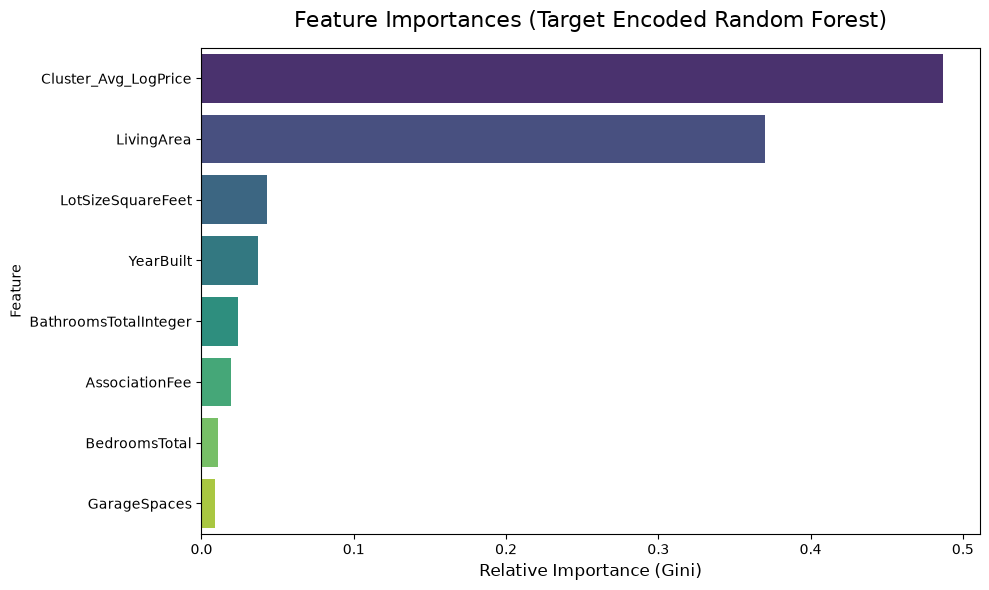

In [9]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Feature Importances (Target Encoded Random Forest)', fontsize=16, pad=15)
plt.xlabel('Relative Importance (Gini)', fontsize=12)
plt.tight_layout()
plt.show()

Through feature importance analysis, we found that California home prices are overwhelmingly driven by *‘micro-location premium’ (48%)** and ‘interior area’ (37%)**. This confirms that our strategy of using Target Encoding to compress sparse geographic coordinates into continuous location value features was extremely successful, as it directly helped the tree model capture the most important business signals.